In [ ]:
!cd /content/drive/MyDrive/liya_diploma && git pull

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 5 (delta 2), reused 5 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 974 bytes | 6.00 KiB/s, done.
From https://github.com/Superpevel/liya_diploma
   79f2ca3..ed3d07c  main       -> origin/main
Updating 79f2ca3..ed3d07c
Fast-forward
 requirements.txt | 39 +++++++++++++++++++++------------------
 1 file changed, 21 insertions(+), 18 deletions(-)


In [ ]:
import sys
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive/liya_diploma'
    AI_TOOLKIT = '/content/ai-toolkit'
    sys.path.insert(0, DRIVE_ROOT)
    sys.path.insert(0, AI_TOOLKIT)
    # Colab-only: install runtime deps. Local installs are handled by setup_local.{ps1,sh}.
    get_ipython().system('pip install -q resvg-py datasets huggingface-hub Pillow tqdm')
except ModuleNotFoundError:
    # Local run: find project root by looking for scripts/ directory
    _here = Path().resolve()
    DRIVE_ROOT = str(_here if (_here / 'scripts').exists() else _here.parent)
    AI_TOOLKIT = str(Path(DRIVE_ROOT).parent / 'ai-toolkit')
    sys.path.insert(0, DRIVE_ROOT)
    sys.path.insert(0, AI_TOOLKIT)

print(f"DRIVE_ROOT: {DRIVE_ROOT}")

SVG_DIR = f'{DRIVE_ROOT}/data/raw_svg'
PNG_DIR = f'{DRIVE_ROOT}/data/png_512'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DRIVE_ROOT: /content/drive/MyDrive/liya_diploma


In [ ]:
DATASETS = [
    ("iamkaikai/amazing_logos_v4",         "image", "text"),  # ~150k, has captions
    ("logo-wizard/modern-logo-dataset",    "image", "text"),  # ~800, has captions
]

# Cap per dataset to keep captioning + training tractable.
# 5000 from amazing-logos-v4 + 800 from modern-logo = ~5800 pairs total.
# Bump MAX_PER_DATASET if you have time + Drive space.
MAX_PER_DATASET = 5000

from datasets import load_dataset

datasets_list = []
for ds_id, img_field, cap_field in DATASETS:
    print(f"Loading {ds_id}...")
    ds = load_dataset(ds_id, split="train")
    if MAX_PER_DATASET and len(ds) > MAX_PER_DATASET:
        ds = ds.shuffle(seed=42).select(range(MAX_PER_DATASET))
    print(f"  kept {len(ds)} samples (image='{img_field}', caption='{cap_field}')")
    datasets_list.append((ds_id, ds, img_field, cap_field))

total = sum(len(ds) for _, ds, _, _ in datasets_list)
print(f"\nTotal: {total} samples across {len(datasets_list)} datasets")


Loading iamkaikai/amazing_logos_v4...


README.md:   0%|          | 0.00/408 [00:00<?, ?B/s]

data/train-00000-of-00014-8fa0be170a1cb1(…):   0%|          | 0.00/795M [00:00<?, ?B/s]

data/train-00001-of-00014-37a1302a48bbd8(…):   0%|          | 0.00/1.04G [00:00<?, ?B/s]

data/train-00002-of-00014-2a126a6df42736(…):   0%|          | 0.00/1.04G [00:00<?, ?B/s]

...

data/train-00012-of-00014-00457bc96a8beb(…):   0%|          | 0.00/1.03G [00:00<?, ?B/s]

data/train-00013-of-00014-e2a2aefd0807aa(…):   0%|          | 0.00/1.03G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/397251 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/29 [00:00<?, ?it/s]

  kept 5000 samples (image='image', caption='text')
Loading logo-wizard/modern-logo-dataset...
  kept 803 samples (image='image', caption='text')

Total: 5803 samples across 2 datasets


In [ ]:
from pathlib import Path
from tqdm import tqdm
from PIL import Image
import json

Path(SVG_DIR).mkdir(parents=True, exist_ok=True)
Path(PNG_DIR).mkdir(parents=True, exist_ok=True)
print(f"PNG_DIR = {PNG_DIR}")
print(f"datasets_list has {len(datasets_list)} datasets, "
      f"{sum(len(ds) for _, ds, _, _ in datasets_list)} total samples")

# Pre-built caption table: png_path -> caption.
# Items present here can skip notebook 02 (LLaVA captioning).
prebuilt_captions = {}

idx = 0
n_svg, n_png, n_skip = 0, 0, 0
for ds_id, ds, img_field, cap_field in datasets_list:
    for item in tqdm(ds, desc=ds_id):
        # SVG-bearing record: dump and let cell-04 rasterise.
        if item.get("svg"):
            with open(f"{SVG_DIR}/{idx:06d}.svg", "w", encoding="utf-8") as f:
                f.write(item["svg"])
            n_svg += 1
            idx += 1
            continue

        img = item.get(img_field)
        if img is None:
            n_skip += 1
            continue

        # Square pad on white, then 512x512.
        img = img.convert("RGB")
        side = max(img.size)
        canvas = Image.new("RGB", (side, side), (255, 255, 255))
        canvas.paste(img, ((side - img.size[0]) // 2, (side - img.size[1]) // 2))
        png_path = f"{PNG_DIR}/{idx:06d}.png"
        canvas.resize((512, 512), Image.LANCZOS).save(png_path, "PNG")
        n_png += 1

        if cap_field and item.get(cap_field):
            prebuilt_captions[png_path] = item[cap_field]

        idx += 1

print(f"\nSaved {n_svg} SVG -> {SVG_DIR}")
print(f"Saved {n_png} PNG -> {PNG_DIR}")
if n_skip:
    print(f"Skipped {n_skip} items with missing image field")
print(f"Pre-built captions: {len(prebuilt_captions)} (notebook 02 will skip these)")

# Persist for notebook 02.
prebuilt_path = f"{DRIVE_ROOT}/data/prebuilt_captions.json"
if prebuilt_captions:
    with open(prebuilt_path, "w", encoding="utf-8") as f:
        json.dump(prebuilt_captions, f, ensure_ascii=False, indent=2)
    print(f"Saved {prebuilt_path}")

In [ ]:
from pathlib import Path
from scripts.svg_to_png import batch_convert

svg_files = list(Path(SVG_DIR).glob("**/*.svg"))
if svg_files:
    stats = batch_convert(SVG_DIR, PNG_DIR, size=512)
    print(f"Converted: {stats['success']} OK, {stats['failed']} failed of {stats['total']}")
else:
    n_pngs = len(list(Path(PNG_DIR).glob("*.png")))
    print(f"No SVG files in {SVG_DIR} - dataset is PNG-only.")
    print(f"PNG_DIR already has {n_pngs} images, skipping rasterisation.")


In [24]:
import importlib
import json
import scripts.filter_dataset
importlib.reload(scripts.filter_dataset)
from scripts.filter_dataset import filter_dataset

filtered = filter_dataset(PNG_DIR, SVG_DIR, min_paths=3, max_paths=500)
print(f"After filtering: {len(filtered)} valid pairs")

with open(f'{DRIVE_ROOT}/data/filtered_pairs.jsonl', 'w') as f:
    for item in filtered:
        f.write(json.dumps(item) + '\n')
print("Saved data/filtered_pairs.jsonl")


After filtering: 10000 valid pairs
Saved data/filtered_pairs.jsonl


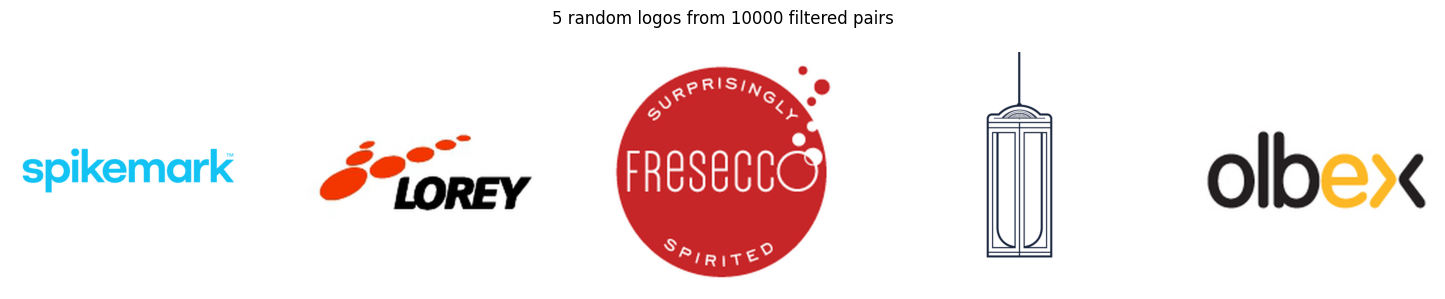

In [25]:
import random
import os
from PIL import Image
import matplotlib.pyplot as plt

if not filtered:
    print("No filtered pairs to preview - check earlier cells (PNG_DIR empty or aspect-ratio filter too strict).")
else:
    sample = random.sample(filtered, min(5, len(filtered)))
    fig, axes = plt.subplots(1, len(sample), figsize=(15, 3), squeeze=False)
    axes = axes[0]
    for ax, item in zip(axes, sample):
        ax.imshow(Image.open(item['png_path']))
        ax.axis('off')
    plt.suptitle(f"{len(sample)} random logos from {len(filtered)} filtered pairs")
    plt.tight_layout()
    out_path = f'{DRIVE_ROOT}/results/experiments/dataset_sample.png'
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=150)
    plt.show()
